In [4]:
import pandas as pd
from rapidfuzz import fuzz
import fuzzy
import matplotlib.pyplot as plt
from tabulate import tabulate
from Levenshtein import distance as levenshtein_distance
import numpy as np
import skfuzzy as fuzz_control
import skfuzzy.control as ctrl

# Завантаження датасету
df = pd.read_csv('corner_cases_new.csv', encoding='latin1')

# Функція для очищення рядків від непотрібних символів
def clean_string(s):
    return s.replace('\xa0', ' ').strip()

# Функція для обчислення Soundex
soundex = fuzzy.Soundex(4)
def soundex_similarity(str1, str2):
    str1 = clean_string(str1)  # Очистка першого рядка
    str2 = clean_string(str2)  # Очистка другого рядка
    return int(soundex(str1) == soundex(str2)) * 100

# Функція для обчислення Damerau-Levenshtein відстані
def damerau_levenshtein_distance(str1, str2):
    return levenshtein_distance(str1, str2)

# Функція для обчислення ймовірності належності на основі вагових коефіцієнтів
def calculate_similarity(name_jw, name_soundex):
    return round((name_jw * 0.9 + name_soundex * 0.1), 2)

# Створення таблиці порівнянь між значеннями Name1 і Name2
def create_comparison_table(df, threshold=75):
    results = []
    filtered_results = []

    for i in range(len(df)):
        for j in range(len(df)):
            if i != j:
                name_jw = fuzz.token_sort_ratio(df.loc[i, 'Name1'], df.loc[j, 'Name2']) / 100
                name_soundex = soundex_similarity(df.loc[i, 'Name1'], df.loc[j, 'Name2']) / 100

                distance = damerau_levenshtein_distance(df.loc[i, 'Name1'], df.loc[j, 'Name2'])
                probability = calculate_similarity(name_jw, name_soundex)
                probability_percentage = int(probability * 100)

                # Застосовуємо поріг для вирішення, чи належить
                decision = "Належить" if probability_percentage >= threshold else "Не належить"

                row = [
                    df.loc[i, 'Name1'], df.loc[j, 'Name2'],
                    round(name_jw, 2), round(name_soundex, 2),
                    distance, f"{probability_percentage}%", decision
                ]

                # Збереження всіх рядків для текстового файлу
                results.append(row)

                # Фільтрація лише тих рядків, де ймовірність належності більше 60%
                if probability_percentage > 60:
                    filtered_results.append(row)

    headers = [
        "Name1", "Name2",
        "Name JW", "Name Soundex",
        "Damerau-Levenshtein", "Ймовірність належності", "Рішення"
    ]

    # Виведення в Jupyter тих рядків, де ймовірність належності більше 60
    table_filtered = tabulate(filtered_results, headers=headers, tablefmt="grid", stralign="center", numalign="center")
    print("\nТаблиця порівнянь (ймовірність належності > 60%):")
    print(table_filtered)

    # Зберігання таблиці в файл
    table_all = tabulate(results, headers=headers, tablefmt="grid", stralign="center", numalign="center")
    with open('comparison_table.txt', 'w', encoding='utf-8') as f:
        f.write(table_all)

    print("\nТаблиця порівнянь збережена у файл 'comparison_table.txt'.")



# Виклик функції для створення таблиці
create_comparison_table(df, threshold=75)



Таблиця порівнянь (ймовірність належності > 60%):
+----------------------------+----------------------------+-----------+----------------+-----------------------+--------------------------+-------------+
|           Name1            |           Name2            |  Name JW  |  Name Soundex  |  Damerau-Levenshtein  |  Ймовірність належності  |   Рішення   |
+============================+============================+===========+================+=======================+==========================+=============+
|        Mehul Gupta         |         Mehl Gutta         |   0.86    |       0        |           2           |           77%            |  Належить   |
+----------------------------+----------------------------+-----------+----------------+-----------------------+--------------------------+-------------+
|        Mehul Gupta         |        Mehul Gustaf        |   0.87    |       0        |           2           |           78%            |  Належить   |
+------------------------

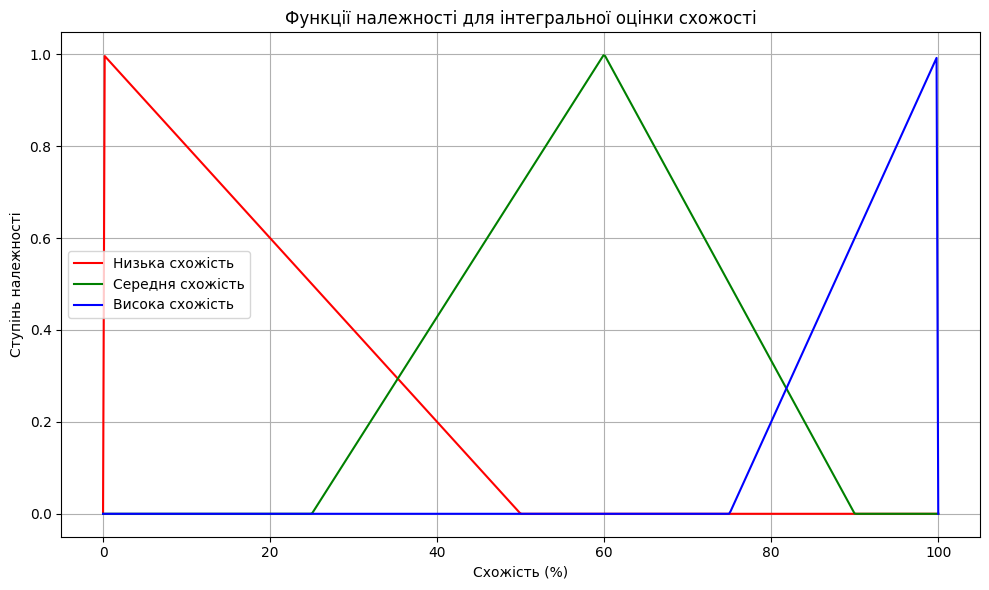

In [15]:
def trimf(x, params):
    a, b, c = params
    return np.maximum(np.minimum((x - a) / (b - a + 1e-6), (c - x) / (c - b + 1e-6)), 0)

def plot_overall_membership():
    x = np.linspace(0, 100, 500)

    y_low = trimf(x, [0, 0, 50])
    y_med = trimf(x, [25, 60, 90])
    y_high = trimf(x, [75, 100, 100])

    plt.figure(figsize=(10, 6))
    plt.plot(x, y_low, label='Низька схожість', color='r')
    plt.plot(x, y_med, label='Середня схожість', color='g')
    plt.plot(x, y_high, label='Висока схожість', color='b')

    plt.title("Функції належності для інтегральної оцінки схожості")
    plt.xlabel("Схожість (%)")
    plt.ylabel("Ступінь належності")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Виклик
plot_overall_membership()

Виконуючи лабораторну роботу, я реалізувала порівняння рядків за допомогою метрик Jaro-Winkler, Soundex і Damerau-Levenshtein. Обчислила ймовірність належності між парами рядків і створила таблицю порівнянь, де фільтрувала результати з ймовірністю вище 75%. Також візуалізувала функції належності для інтегральної оцінки схожості, що дозволило наочно побачити вплив різних ступенів схожості на результат.

У результаті таблиця порівнянь була занесена до файлу comparison_table.txt, де значення "Належить" було присвоєно лише тим рядкам, чия ймовірність належності була більше 75%, а також було виведено в Jupyter ті рядки, де ймовірність належності більше 60.